# Three-Level Extraction and Merge Walkthrough

This notebook demonstrates step-by-step extraction from three levels:
1. **ADE (Agentic Document Extraction)** - Layout-aware chunks with semantic types
2. **PDF Text Layer** - Native text extraction from PDF structure
3. **OCR (Google Document AI)** - Optical character recognition from rendered images

The workflow:
1. Extract from all three levels independently
2. Merge PDF + OCR by considering bounding box overlaps and text similarity
3. Assign each merged bounding box to its corresponding ADE tag/chunk
4. Visualize results with color-coded overlays


In [ ]:
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import fitz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import toml
from IPython.display import display
from matplotlib.patches import Rectangle

from hybrid_page_extractor import (
    extract_page_sources,
    normalize_document_ai_config,
    extract_pdf_text_words,
    run_document_ai_ocr,
    normalize_text_for_matching,
)
from utils_ade_official import align_ade_chunks_to_page, ade_parse_document_official

plt.rcParams["figure.dpi"] = 144
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", None)


✅ Comprehensive text extraction available


In [ ]:
# Configuration
SECRETS_PATH = Path(".streamlit/secrets.toml")
if not SECRETS_PATH.exists():
    raise FileNotFoundError("Expected .streamlit/secrets.toml with API keys.")

secrets = toml.load(SECRETS_PATH)

ADE_API_KEY = secrets.get("LANDINGAI_API_KEY")
if not ADE_API_KEY:
    raise ValueError("Missing LANDINGAI_API_KEY in secrets.toml")

PDF_PATH = Path("subset_gold/selected_pages_no_annotations.pdf")
PAGE_NUMBER = 2  # change here to inspect a different page

raw_doc_ai_config: Optional[Dict] = None
if "google_cloud" in secrets and "gcp_service_account" in secrets:
    raw_doc_ai_config = {
        "project_number": secrets["google_cloud"].get("project_number"),
        "location": secrets["google_cloud"].get("location"),
        "processor_id": secrets["google_cloud"].get("processor_id"),
        "service_account_info": dict(secrets["gcp_service_account"]),
    }
    doc_ai_config = normalize_document_ai_config(raw_doc_ai_config)
else:
    doc_ai_config = None
    print("⚠️ Google Cloud credentials missing; OCR results will be empty.")

# Open PDF
pdf_doc = fitz.open(str(PDF_PATH))
page_index = PAGE_NUMBER - 1
if page_index < 0 or page_index >= len(pdf_doc):
    raise IndexError(f"Page {PAGE_NUMBER} out of bounds for document with {len(pdf_doc)} pages")

pdf_page = pdf_doc[page_index]
page_width = float(pdf_page.rect.width)
page_height = float(pdf_page.rect.height)

print(f"PDF: {PDF_PATH} → {len(pdf_doc)} pages")
print(f"Inspecting page {PAGE_NUMBER} (0-based index {page_index})")
print(f"Page size: {page_width:.1f} × {page_height:.1f} pts")
if doc_ai_config and doc_ai_config.get("client"):
    print("✅ Document AI client initialised")
else:
    print("⚠️ Document AI client not available")


PDF: subset_gold/selected_pages_no_annotations.pdf → 5 pages
Inspecting page 2 (0-based index 1)
Page size: 2592.0 × 1728.0 pts
✅ Document AI client initialised


E0000 00:00:1763346636.111547  747166 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


## Step 1: Extract from Three Levels


In [ ]:
# Step 1.1: Extract PDF text layer words
pdf_words = extract_pdf_text_words(pdf_page)
print(f"✅ PDF text layer: {len(pdf_words)} words extracted")

if pdf_words:
    display(pd.DataFrame(pdf_words).head(10))


✅ PDF text layer: 1620 words extracted


,text,normalized_text,x0,y0,x1,y1,block_no,line_no,word_no
0,T,T,1401.092163,468.661133,1405.279907,473.538239,0,0,0
1,T,T,1421.132202,436.021118,1425.319946,440.898224,1,0,0
2,EV,EV,183.315979,505.478668,185.681030,507.635010,2,0,0
3,JB,J8,688.073181,969.007690,690.764099,971.523376,3,0,0
4,W,W,182.160156,482.252869,184.870834,485.000702,4,0,0
5,W,W,268.679901,618.332825,271.390594,621.080688,5,0,0
6,TF,TF,174.638031,521.225769,177.273819,523.838928,6,0,0
7,TF,TF,189.757996,535.865784,192.393784,538.478943,7,0,0
8,JB,J8,1436.632812,222.127899,1439.323730,224.643616,8,0,0
9,JB,J8,1439.512695,241.567963,1442.203613,244.083679,9,0,0


In [ ]:
# Step 1.2: Extract OCR tokens
ocr_tokens: List[Dict] = []
if doc_ai_config:
    ocr_tokens = run_document_ai_ocr(
        pdf_page,
        client=doc_ai_config.get("client"),
        processor_name=doc_ai_config.get("processor_name"),
        dpi=240,
        config=doc_ai_config.get("ocr_config"),
    )
    print(f"✅ OCR: {len(ocr_tokens)} tokens extracted")
else:
    print("⚠️ OCR skipped (no Document AI config)")

if ocr_tokens:
    display(pd.DataFrame(ocr_tokens).head(10))


✅ OCR: 2011 tokens extracted


,text,normalized_text,x0,y0,x1,y1,confidence,attempt_dpi
0,542,542,190.887307,292.544538,212.610555,304.560585,0.762378,210
1,°,°,210.299576,290.695899,215.383744,293.931004,0.664517,210
2,43,43,218.156914,286.998673,232.485015,296.703936,0.977836,210
3,',',230.174037,286.074354,233.409418,288.847286,0.870761,210
4,14.45,14.45,236.644800,277.293386,263.914407,291.620218,0.969973,210
5,"""","""",263.452215,277.293386,267.149788,280.528490,0.856562,210
6,W,W,265.763193,274.982626,276.393721,284.225741,0.627641,210
7,L,L,285.637654,271.285375,293.032820,279.142024,0.938231,210
8,=,=,293.495012,273.133987,297.654777,275.906919,0.543547,210
9,124.48,124.48,297.654777,266.201657,331.857358,277.755558,0.967566,210


In [ ]:
# Step 1.3: Extract ADE chunks
pdf_bytes = PDF_PATH.read_bytes()
ade_result = ade_parse_document_official(pdf_bytes, ADE_API_KEY)

if not ade_result.get("success"):
    raise ValueError(f"ADE parsing failed: {ade_result.get('error')}")

ade_chunks = align_ade_chunks_to_page(ade_result, page_index, page_width, page_height)
print(f"✅ ADE: {len(ade_chunks)} chunks extracted")

if ade_chunks:
    display(pd.DataFrame(ade_chunks)[["id", "type", "x0", "y0", "x1", "y1", "markdown"]].head(10))


✅ ADE: 19 chunks extracted


,id,type,x0,y0,x1,y1,markdown
0,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,figure,136.068051,31.985355,1489.177448,1280.020145,<a id='1723b0dc-6eb8-4a5d-830b-ac7e09b673c3'><...
1,45f3892c-8792-46f0-9332-d2c73408ee6d,table,588.969880,1279.166714,1493.378946,1701.858685,<a id='45f3892c-8792-46f0-9332-d2c73408ee6d'><...
2,906493b9-ae4d-41e2-a691-67fbc6a68601,text,1488.795382,33.355419,1939.974936,255.497892,<a id='906493b9-ae4d-41e2-a691-67fbc6a68601'><...
3,17b91947-892e-4db4-ab01-040fac33b3c8,text,1488.134605,255.449175,1940.470402,471.657280,<a id='17b91947-892e-4db4-ab01-040fac33b3c8'><...
4,33a78f8b-9f95-49f5-9a74-40aeb309636b,text,1487.131931,471.103363,1941.108467,1156.963348,<a id='33a78f8b-9f95-49f5-9a74-40aeb309636b'><...
5,04c3701e-d4b6-4f59-9722-df3c2c3f03ed,text,1488.809904,1156.452690,1940.896345,1317.141541,<a id='04c3701e-d4b6-4f59-9722-df3c2c3f03ed'><...
6,ace512ba-cd84-46b1-8d20-daf5ef489935,figure,1492.383224,1317.585972,1943.352356,1701.720669,<a id='ace512ba-cd84-46b1-8d20-daf5ef489935'><...
7,236c9064-1a0e-4aad-9f51-15ba3c12b4bd,text,1943.694872,34.719767,2391.016989,1026.824387,<a id='236c9064-1a0e-4aad-9f51-15ba3c12b4bd'><...
8,efe17152-4b70-4efa-838e-a74803ff1bc1,logo,2392.656183,29.408169,2586.948469,251.908015,<a id='efe17152-4b70-4efa-838e-a74803ff1bc1'><...
9,343d5c14-1b68-4a0d-8e9e-31ddee446ce8,logo,2399.403454,254.236954,2584.570015,394.215408,<a id='343d5c14-1b68-4a0d-8e9e-31ddee446ce8'><...


## Step 2: Merge PDF + OCR

We merge PDF and OCR tokens by:
1. Finding overlapping bounding boxes
2. Checking text similarity
3. Creating unified entries with best text and combined bounding boxes


In [ ]:
def calculate_overlap_ratio(bbox1: Dict, bbox2: Dict) -> float:
    """Calculate overlap ratio between two bounding boxes (relative to smaller box)."""
    x1_min, y1_min = float(bbox1.get("x0", 0)), float(bbox1.get("y0", 0))
    x1_max, y1_max = float(bbox1.get("x1", 0)), float(bbox1.get("y1", 0))
    x2_min, y2_min = float(bbox2.get("x0", 0)), float(bbox2.get("y0", 0))
    x2_max, y2_max = float(bbox2.get("x1", 0)), float(bbox2.get("y1", 0))
    
    # Calculate intersection
    x_left = max(x1_min, x2_min)
    y_top = max(y1_min, y2_min)
    x_right = min(x1_max, x2_max)
    y_bottom = min(y1_max, y2_max)
    
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    
    # Calculate areas
    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)
    
    # Return overlap ratio relative to smaller box
    smaller_area = min(area1, area2)
    if smaller_area == 0:
        return 0.0
    
    return intersection_area / smaller_area


def calculate_text_similarity(text1: str, text2: str) -> float:
    """Calculate text similarity using normalized text matching."""
    norm1 = normalize_text_for_matching(text1)
    norm2 = normalize_text_for_matching(text2)
    
    if not norm1 and not norm2:
        return 1.0
    if not norm1 or not norm2:
        return 0.0
    
    # Check exact match
    if norm1 == norm2:
        return 1.0
    
    # Check if one contains the other
    if norm1 in norm2 or norm2 in norm1:
        return 0.8
    
    # Calculate character overlap
    set1 = set(norm1)
    set2 = set(norm2)
    if not set1 or not set2:
        return 0.0
    
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0.0


def merge_bboxes(bboxes: List[Dict]) -> Dict:
    """Merge multiple bounding boxes into one unified box."""
    if not bboxes:
        return {}
    
    x0_min = min(float(b.get("x0", 0)) for b in bboxes)
    y0_min = min(float(b.get("y0", 0)) for b in bboxes)
    x1_max = max(float(b.get("x1", 0)) for b in bboxes)
    y1_max = max(float(b.get("y1", 0)) for b in bboxes)
    
    return {"x0": x0_min, "y0": y0_min, "x1": x1_max, "y1": y1_max}


def merge_pdf_ocr(
    pdf_words: List[Dict],
    ocr_tokens: List[Dict],
    overlap_threshold: float = 0.3,
    text_similarity_threshold: float = 0.7,
) -> List[Dict]:
    """
    Merge PDF and OCR tokens by finding overlaps and combining them.
    
    Args:
        pdf_words: PDF text layer words
        ocr_tokens: OCR tokens from Google Document AI
        overlap_threshold: Minimum overlap ratio to consider as match
        text_similarity_threshold: Minimum text similarity to merge
    
    Returns:
        List of merged tokens with unified bounding boxes
    """
    merged_tokens: List[Dict] = []
    ocr_used = set()  # Track which OCR tokens have been merged
    
    # Start with PDF words as base
    for pdf_word in pdf_words:
        pdf_bbox = {
            "x0": float(pdf_word.get("x0", 0)),
            "y0": float(pdf_word.get("y0", 0)),
            "x1": float(pdf_word.get("x1", 0)),
            "y1": float(pdf_word.get("y1", 0)),
        }
        pdf_text = pdf_word.get("text", "")
        
        # Find matching OCR tokens
        matching_ocr = []
        for idx, ocr_token in enumerate(ocr_tokens):
            if idx in ocr_used:
                continue
            
            ocr_bbox = {
                "x0": float(ocr_token.get("x0", 0)),
                "y0": float(ocr_token.get("y0", 0)),
                "x1": float(ocr_token.get("x1", 0)),
                "y1": float(ocr_token.get("y1", 0)),
            }
            ocr_text = ocr_token.get("text", "")
            
            # Check overlap
            overlap = calculate_overlap_ratio(pdf_bbox, ocr_bbox)
            if overlap < overlap_threshold:
                continue
            
            # Check text similarity
            similarity = calculate_text_similarity(pdf_text, ocr_text)
            if similarity < text_similarity_threshold:
                continue
            
            matching_ocr.append((idx, ocr_token))
        
        # Merge if matches found
        if matching_ocr:
            # Merge bounding boxes
            all_bboxes = [pdf_bbox] + [ocr_bbox for _, ocr_bbox in matching_ocr]
            merged_bbox = merge_bboxes(all_bboxes)
            
            # Use best text (prefer OCR if it's longer, otherwise PDF)
            texts = [pdf_text] + [ocr_token.get("text", "") for _, ocr_token in matching_ocr]
            best_text = max(texts, key=len)
            
            # Mark OCR tokens as used
            for idx, _ in matching_ocr:
                ocr_used.add(idx)
            
            merged_tokens.append({
                "text": best_text,
                "normalized_text": normalize_text_for_matching(best_text),
                "x0": merged_bbox["x0"],
                "y0": merged_bbox["y0"],
                "x1": merged_bbox["x1"],
                "y1": merged_bbox["y1"],
                "source": "pdf+ocr",
                "sources_count": 1 + len(matching_ocr),
                "original_pdf_text": pdf_text,
                "original_ocr_text": ", ".join([ocr_token.get("text", "") for _, ocr_token in matching_ocr]),
            })
        else:
            # No match, keep PDF word as-is
            merged_tokens.append({
                "text": pdf_text,
                "normalized_text": normalize_text_for_matching(pdf_text),
                "x0": pdf_bbox["x0"],
                "y0": pdf_bbox["y0"],
                "x1": pdf_bbox["x1"],
                "y1": pdf_bbox["y1"],
                "source": "pdf_only",
                "sources_count": 1,
                "original_pdf_text": pdf_text,
                "original_ocr_text": "",
            })
    
    # Add remaining OCR tokens that weren't matched
    for idx, ocr_token in enumerate(ocr_tokens):
        if idx in ocr_used:
            continue
        
        ocr_bbox = {
            "x0": float(ocr_token.get("x0", 0)),
            "y0": float(ocr_token.get("y0", 0)),
            "x1": float(ocr_token.get("x1", 0)),
            "y1": float(ocr_token.get("y1", 0)),
        }
        ocr_text = ocr_token.get("text", "")
        
        merged_tokens.append({
            "text": ocr_text,
            "normalized_text": normalize_text_for_matching(ocr_text),
            "x0": ocr_bbox["x0"],
            "y0": ocr_bbox["y0"],
            "x1": ocr_bbox["x1"],
            "y1": ocr_bbox["y1"],
            "source": "ocr_only",
            "sources_count": 1,
            "original_pdf_text": "",
            "original_ocr_text": ocr_text,
        })
    
    return merged_tokens


In [ ]:
# Perform the merge with adjustable thresholds
overlap_threshold = 0.2  # Lower threshold to catch more overlaps
text_similarity_threshold = 0.5  # Lower threshold to catch more text matches

merged_tokens = merge_pdf_ocr(
    pdf_words=pdf_words,
    ocr_tokens=ocr_tokens,
    overlap_threshold=overlap_threshold,
    text_similarity_threshold=text_similarity_threshold,
)

print(f"📊 Merge Summary:")
print(f"  PDF words: {len(pdf_words)}")
print(f"  OCR tokens: {len(ocr_tokens)}")
print(f"  Merged tokens: {len(merged_tokens)}")
print(f"  Merge thresholds: overlap={overlap_threshold}, similarity={text_similarity_threshold}")

# Count by source
source_counts = {}
for token in merged_tokens:
    source = token.get("source", "unknown")
    source_counts[source] = source_counts.get(source, 0) + 1

print(f"\n📈 Source breakdown:")
for source, count in source_counts.items():
    print(f"  {source}: {count}")

if merged_tokens:
    display(pd.DataFrame(merged_tokens).head(15))


📊 Merge Summary:
  PDF words: 1620
  OCR tokens: 2011
  Merged tokens: 1658
  Merge thresholds: overlap=0.2, similarity=0.5

📈 Source breakdown:
  pdf_only: 152
  pdf+ocr: 1468
  ocr_only: 38


,text,normalized_text,x0,y0,x1,y1,source,sources_count,original_pdf_text,original_ocr_text
0,T,T,1401.092163,468.661133,1405.279907,473.538239,pdf_only,1,T,
1,T,T,1421.132202,436.021118,1425.319946,440.898224,pdf_only,1,T,
2,EV,EV,183.315979,505.478668,185.681030,507.635010,pdf_only,1,EV,
3,JB,J8,688.073181,969.007690,690.764099,971.523376,pdf_only,1,JB,
4,W,W,182.160156,482.252869,184.870834,485.000702,pdf_only,1,W,
5,W,W,268.679901,618.332825,271.390594,621.080688,pdf_only,1,W,
6,TF,TF,174.638031,521.225769,177.273819,523.838928,pdf_only,1,TF,
7,TF,TF,189.757996,535.865784,192.393784,538.478943,pdf_only,1,TF,
8,JB,J8,1436.632812,222.127899,1439.323730,224.643616,pdf_only,1,JB,
9,JB,J8,1439.512695,241.567963,1442.203613,244.083679,pdf_only,1,JB,


### Diagnostic: Why Some Tokens Aren't Merged

Let's analyze potential matches that were missed to understand why some tokens don't have both PDF and OCR sources.


In [ ]:
# Diagnostic: Find potential matches that didn't meet thresholds
print("🔍 Analyzing potential missed matches...\n")

# Look at PDF-only tokens and see if there are nearby OCR tokens
pdf_only_tokens = [t for t in merged_tokens if t.get("source") == "pdf_only"]
ocr_only_tokens = [t for t in merged_tokens if t.get("source") == "ocr_only"]

print(f"PDF-only tokens: {len(pdf_only_tokens)}")
print(f"OCR-only tokens: {len(ocr_only_tokens)}\n")

# For each PDF-only token, find the closest OCR token
potential_matches = []
for pdf_token in pdf_only_tokens[:50]:  # Check first 50 to avoid too much output
    pdf_text = pdf_token.get("text", "")
    pdf_bbox = {
        "x0": float(pdf_token.get("x0", 0)),
        "y0": float(pdf_token.get("y0", 0)),
        "x1": float(pdf_token.get("x1", 0)),
        "y1": float(pdf_token.get("y1", 0)),
    }
    
    best_ocr_match = None
    best_overlap = 0.0
    best_similarity = 0.0
    
    for ocr_token in ocr_tokens:
        ocr_text = ocr_token.get("text", "")
        ocr_bbox = {
            "x0": float(ocr_token.get("x0", 0)),
            "y0": float(ocr_token.get("y0", 0)),
            "x1": float(ocr_token.get("x1", 0)),
            "y1": float(ocr_token.get("y1", 0)),
        }
        
        # Calculate distance and overlap
        overlap = calculate_overlap_ratio(pdf_bbox, ocr_bbox)
        similarity = calculate_text_similarity(pdf_text, ocr_text)
        
        # Calculate center distance
        pdf_center_x = (pdf_bbox["x0"] + pdf_bbox["x1"]) / 2
        pdf_center_y = (pdf_bbox["y0"] + pdf_bbox["y1"]) / 2
        ocr_center_x = (ocr_bbox["x0"] + ocr_bbox["x1"]) / 2
        ocr_center_y = (ocr_bbox["y0"] + ocr_bbox["y1"]) / 2
        distance = ((pdf_center_x - ocr_center_x) ** 2 + (pdf_center_y - ocr_center_y) ** 2) ** 0.5
        
        # Keep track of best match (within reasonable distance)
        if distance < 50:  # Within 50 points
            if overlap > best_overlap or (overlap > 0.05 and similarity > best_similarity):
                best_overlap = overlap
                best_similarity = similarity
                best_ocr_match = {
                    "ocr_text": ocr_text,
                    "overlap": overlap,
                    "similarity": similarity,
                    "distance": distance,
                }
    
    if best_ocr_match:
        potential_matches.append({
            "pdf_text": pdf_text[:50],
            "ocr_text": best_ocr_match["ocr_text"][:50],
            "overlap": best_overlap,
            "similarity": best_similarity,
            "distance": best_ocr_match["distance"],
            "would_match": best_overlap >= overlap_threshold and best_similarity >= text_similarity_threshold,
        })

if potential_matches:
    matches_df = pd.DataFrame(potential_matches)
    print(f"Found {len(potential_matches)} potential matches (showing first 20):\n")
    display(matches_df.head(20))
    
    # Show statistics
    would_match_count = sum(1 for m in potential_matches if m["would_match"])
    print(f"\n📊 Of {len(potential_matches)} potential matches:")
    print(f"  Would match with current thresholds: {would_match_count}")
    print(f"  Would not match: {len(potential_matches) - would_match_count}")
    
    if len(potential_matches) - would_match_count > 0:
        print(f"\n💡 Consider lowering thresholds if these should match:")
        near_misses = [m for m in potential_matches if not m["would_match"] and (m["overlap"] > 0.1 or m["similarity"] > 0.3)]
        if near_misses:
            print(f"  Found {len(near_misses)} near-misses (overlap > 0.1 or similarity > 0.3)")
            display(pd.DataFrame(near_misses[:10]))
else:
    print("No potential matches found in sample (this might be normal if PDF and OCR already match well)")


🔍 Analyzing potential missed matches...

PDF-only tokens: 152
OCR-only tokens: 38

Found 9 potential matches (showing first 20):



,pdf_text,ocr_text,overlap,similarity,distance,would_match
0,IV,E,0.022687,0.0,8.255353,False
1,IV,00.47,1.000000,0.0,13.710677,False
2,IV,00.47,1.000000,0.0,7.958282,False
3,W,N45,1.000000,0.0,2.857042,False
4,W,N45,1.000000,0.0,6.809479,False
5,IV,N45,0.152543,0.0,14.422704,False
6,W,"""",0.619849,0.0,3.387625,False
7,T,N89,1.000000,0.0,3.255831,False
8,SS,CORPORATE,1.000000,0.0,12.372170,False



📊 Of 9 potential matches:
  Would match with current thresholds: 0
  Would not match: 9

💡 Consider lowering thresholds if these should match:
  Found 8 near-misses (overlap > 0.1 or similarity > 0.3)


,pdf_text,ocr_text,overlap,similarity,distance,would_match
0,IV,00.47,1.000000,0.0,13.710677,False
1,IV,00.47,1.000000,0.0,7.958282,False
2,W,N45,1.000000,0.0,2.857042,False
3,W,N45,1.000000,0.0,6.809479,False
4,IV,N45,0.152543,0.0,14.422704,False
5,W,"""",0.619849,0.0,3.387625,False
6,T,N89,1.000000,0.0,3.255831,False
7,SS,CORPORATE,1.000000,0.0,12.372170,False


## Important Notes About Merge Results

**Yes, OCR and PDF extraction are done on the entire page.** Both extractors process the full page.

**Why some tokens only have PDF or OCR (not both):**

1. **Coordinate alignment differences**: PDF text layer coordinates come directly from the PDF structure, while OCR coordinates come from analyzing a rendered image. Small coordinate differences can prevent matching even when they represent the same text.

2. **Different text granularity**: PDF might split text into individual words, while OCR might group them differently (e.g., "INDUSTRIAL" vs "INDUSTRIAL WAREHOUSE").

3. **Text that exists only in one source**:
   - **PDF-only**: Text in selectable PDF text layer but not visible/readable in the rendered image
   - **OCR-only**: Text in images/drawings that doesn't exist in PDF text layer (common in scanned documents)

4. **Threshold settings**: The overlap and text similarity thresholds determine how strict the matching is. Lower thresholds = more matches, but might create false matches.

**What the merge does:**
- Finds tokens where PDF and OCR bounding boxes overlap significantly
- Checks if the text content is similar
- Creates unified tokens with merged bounding boxes and the best text
- Keeps unmatched tokens as "pdf_only" or "ocr_only"

**If you see many unmatched tokens where you expect matches:**
- Try lowering the thresholds (already set to 0.2 overlap, 0.5 similarity)
- Check the diagnostic cell above to see why specific tokens aren't matching
- Consider that some differences are expected and normal


In [ ]:
def calculate_iou(token_bbox: Dict, chunk_bbox: Dict) -> float:
    """Calculate Intersection over Union (IoU) between two bounding boxes."""
    token_x0 = float(token_bbox.get("x0", 0))
    token_y0 = float(token_bbox.get("y0", 0))
    token_x1 = float(token_bbox.get("x1", 0))
    token_y1 = float(token_bbox.get("y1", 0))
    
    chunk_x0 = float(chunk_bbox.get("x0", 0))
    chunk_y0 = float(chunk_bbox.get("y0", 0))
    chunk_x1 = float(chunk_bbox.get("x1", 0))
    chunk_y1 = float(chunk_bbox.get("y1", 0))
    
    # Calculate intersection
    intersect_x0 = max(token_x0, chunk_x0)
    intersect_y0 = max(token_y0, chunk_y0)
    intersect_x1 = min(token_x1, chunk_x1)
    intersect_y1 = min(token_y1, chunk_y1)
    
    if intersect_x0 >= intersect_x1 or intersect_y0 >= intersect_y1:
        return 0.0
    
    intersect_area = (intersect_x1 - intersect_x0) * (intersect_y1 - intersect_y0)
    
    # Calculate union
    token_area = (token_x1 - token_x0) * (token_y1 - token_y0)
    chunk_area = (chunk_x1 - chunk_x0) * (chunk_y1 - chunk_y0)
    union_area = token_area + chunk_area - intersect_area
    
    if union_area <= 0:
        return 0.0
    
    return intersect_area / union_area


def point_in_box(x: float, y: float, bbox: Dict) -> bool:
    """Check if a point is inside a bounding box."""
    return (
        bbox.get("x0", 0) <= x <= bbox.get("x1", 0) and
        bbox.get("y0", 0) <= y <= bbox.get("y1", 0)
    )


def assign_ade_tag_to_token(
    token: Dict,
    ade_chunks: List[Dict],
    min_overlap_ratio: float = 0.1,
    prefer_contained: bool = True,
) -> Optional[Dict]:
    """
    Assign an ADE chunk tag to a token based on bounding box overlap.
    
    Improved logic:
    1. Prefer chunks where token center is contained
    2. Use IoU for better overlap calculation
    3. Consider both token overlap and chunk overlap ratios
    
    Args:
        token: Token dict with x0, y0, x1, y1
        ade_chunks: List of ADE chunks with x0, y0, x1, y1 and type
        min_overlap_ratio: Minimum overlap ratio to consider a match
        prefer_contained: Prefer chunks that contain the token center
    
    Returns:
        Dict with ADE tag info, or None if no match
    """
    token_x0 = float(token.get("x0", 0))
    token_y0 = float(token.get("y0", 0))
    token_x1 = float(token.get("x1", 0))
    token_y1 = float(token.get("y1", 0))
    
    token_area = (token_x1 - token_x0) * (token_y1 - token_y0)
    if token_area <= 0:
        return None
    
    token_center_x = (token_x0 + token_x1) / 2
    token_center_y = (token_y0 + token_y1) / 2
    
    token_bbox = {"x0": token_x0, "y0": token_y0, "x1": token_x1, "y1": token_y1}
    
    best_match = None
    best_score = -1.0
    
    for chunk in ade_chunks:
        chunk_x0 = float(chunk.get("x0", 0))
        chunk_y0 = float(chunk.get("y0", 0))
        chunk_x1 = float(chunk.get("x1", 0))
        chunk_y1 = float(chunk.get("y1", 0))
        
        chunk_bbox = {"x0": chunk_x0, "y0": chunk_y0, "x1": chunk_x1, "y1": chunk_y1}
        
        # Calculate intersection
        intersect_x0 = max(token_x0, chunk_x0)
        intersect_y0 = max(token_y0, chunk_y0)
        intersect_x1 = min(token_x1, chunk_x1)
        intersect_y1 = min(token_y1, chunk_y1)
        
        # Check if there's any overlap
        if intersect_x0 < intersect_x1 and intersect_y0 < intersect_y1:
            # Calculate overlap area
            intersect_area = (intersect_x1 - intersect_x0) * (intersect_y1 - intersect_y0)
            
            # Calculate multiple metrics
            overlap_ratio_token = intersect_area / token_area if token_area > 0 else 0.0
            
            chunk_area = (chunk_x1 - chunk_x0) * (chunk_y1 - chunk_y0)
            overlap_ratio_chunk = intersect_area / chunk_area if chunk_area > 0 else 0.0
            
            # Calculate IoU
            iou = calculate_iou(token_bbox, chunk_bbox)
            
            # Check if token center is contained in chunk
            is_contained = point_in_box(token_center_x, token_center_y, chunk_bbox)
            
            # Score: prefer contained tokens, higher IoU, higher overlap
            score = iou * 2.0  # IoU is weighted most heavily
            if is_contained and prefer_contained:
                score += 1.0  # Bonus for contained tokens
            score += overlap_ratio_token * 0.5  # Token overlap matters
            score += overlap_ratio_chunk * 0.3  # Chunk overlap matters less
            
            # Only consider if meets minimum threshold
            if overlap_ratio_token >= min_overlap_ratio and score > best_score:
                best_score = score
                best_match = {
                    "ade_id": chunk.get("id", ""),
                    "ade_type": chunk.get("type", ""),
                    "ade_x0": chunk_x0,
                    "ade_y0": chunk_y0,
                    "ade_x1": chunk_x1,
                    "ade_y1": chunk_y1,
                    "overlap_ratio": overlap_ratio_token,
                    "overlap_ratio_chunk": overlap_ratio_chunk,
                    "iou": iou,
                    "is_contained": is_contained,
                    "score": score,
                    "overlap_area": intersect_area,
                }
    
    return best_match


# Assign ADE tags to all merged tokens with improved logic
merged_tokens_with_tags: List[Dict] = []

for token in merged_tokens:
    token_with_tag = token.copy()
    ade_tag_info = assign_ade_tag_to_token(
        token, 
        ade_chunks, 
        min_overlap_ratio=0.05,  # Lower threshold to catch more tokens
        prefer_contained=True,   # Prefer chunks that contain token center
    )
    
    if ade_tag_info:
        token_with_tag["ade_assigned"] = True
        token_with_tag["ade_id"] = ade_tag_info.get("ade_id", "")
        token_with_tag["ade_type"] = ade_tag_info.get("ade_type", "")
        token_with_tag["ade_overlap_ratio"] = ade_tag_info.get("overlap_ratio", 0.0)
        token_with_tag["ade_iou"] = ade_tag_info.get("iou", 0.0)
        token_with_tag["ade_is_contained"] = ade_tag_info.get("is_contained", False)
        token_with_tag["ade_score"] = ade_tag_info.get("score", 0.0)
    else:
        token_with_tag["ade_assigned"] = False
        token_with_tag["ade_id"] = None
        token_with_tag["ade_type"] = None
        token_with_tag["ade_overlap_ratio"] = 0.0
        token_with_tag["ade_iou"] = 0.0
        token_with_tag["ade_is_contained"] = False
        token_with_tag["ade_score"] = 0.0
    
    merged_tokens_with_tags.append(token_with_tag)

print(f"📊 ADE Tag Assignment:")
assigned_count = sum(1 for t in merged_tokens_with_tags if t.get("ade_assigned"))
unassigned_count = len(merged_tokens_with_tags) - assigned_count
print(f"  Assigned to ADE chunks: {assigned_count}")
print(f"  Unassigned: {unassigned_count}")

# Count by ADE type
type_counts = {}
for token in merged_tokens_with_tags:
    if token.get("ade_assigned"):
        ade_type = token.get("ade_type", "unknown")
        type_counts[ade_type] = type_counts.get(ade_type, 0) + 1

print(f"\n📈 Tokens by ADE type:")
for ade_type, count in sorted(type_counts.items()):
    print(f"  {ade_type}: {count}")

if merged_tokens_with_tags:
    display_cols = ["text", "source", "ade_assigned", "ade_type", "ade_overlap_ratio", "x0", "y0", "x1", "y1"]
    available_cols = [c for c in display_cols if c in merged_tokens_with_tags[0]]
    display(pd.DataFrame(merged_tokens_with_tags)[available_cols].head(20))


📊 ADE Tag Assignment:
  Assigned to ADE chunks: 1658
  Unassigned: 0

📈 Tokens by ADE type:
  figure: 281
  logo: 98
  table: 198
  text: 1081


,text,source,ade_assigned,ade_type,ade_overlap_ratio,x0,y0,x1,y1
0,T,pdf_only,True,figure,1.0,1401.092163,468.661133,1405.279907,473.538239
1,T,pdf_only,True,figure,1.0,1421.132202,436.021118,1425.319946,440.898224
2,EV,pdf_only,True,figure,1.0,183.315979,505.478668,185.681030,507.635010
3,JB,pdf_only,True,figure,1.0,688.073181,969.007690,690.764099,971.523376
4,W,pdf_only,True,figure,1.0,182.160156,482.252869,184.870834,485.000702
5,W,pdf_only,True,figure,1.0,268.679901,618.332825,271.390594,621.080688
6,TF,pdf_only,True,figure,1.0,174.638031,521.225769,177.273819,523.838928
7,TF,pdf_only,True,figure,1.0,189.757996,535.865784,192.393784,538.478943
8,JB,pdf_only,True,figure,1.0,1436.632812,222.127899,1439.323730,224.643616
9,JB,pdf_only,True,figure,1.0,1439.512695,241.567963,1442.203613,244.083679


### Diagnostic: ADE Tag Assignment Quality

Let's check if tokens are being assigned to the correct ADE chunks.


In [ ]:
# Diagnostic: Check ADE tag assignment quality
print("🔍 ADE Tag Assignment Diagnostic\n")

# Group tokens by ADE type
tokens_by_ade_type = {}
for token in merged_tokens_with_tags:
    if token.get("ade_assigned"):
        ade_type = token.get("ade_type", "unknown")
        if ade_type not in tokens_by_ade_type:
            tokens_by_ade_type[ade_type] = []
        tokens_by_ade_type[ade_type].append(token)

# Show statistics per ADE type
print("📊 Tokens by ADE type:")
for ade_type in sorted(tokens_by_ade_type.keys()):
    tokens = tokens_by_ade_type[ade_type]
    avg_overlap = sum(t.get("ade_overlap_ratio", 0) for t in tokens) / len(tokens) if tokens else 0
    avg_iou = sum(t.get("ade_iou", 0) for t in tokens) / len(tokens) if tokens else 0
    contained_count = sum(1 for t in tokens if t.get("ade_is_contained", False))
    contained_pct = (contained_count / len(tokens) * 100) if tokens else 0
    
    print(f"\n  {ade_type}:")
    print(f"    Total tokens: {len(tokens)}")
    print(f"    Avg overlap ratio: {avg_overlap:.3f}")
    print(f"    Avg IoU: {avg_iou:.3f}")
    print(f"    Contained (center in chunk): {contained_count} ({contained_pct:.1f}%)")

# Show tokens with low quality assignments
low_quality_tokens = [
    t for t in merged_tokens_with_tags 
    if t.get("ade_assigned") and (
        t.get("ade_overlap_ratio", 0) < 0.3 or 
        t.get("ade_iou", 0) < 0.2 or
        not t.get("ade_is_contained", False)
    )
]

if low_quality_tokens:
    print(f"\n⚠️ Found {len(low_quality_tokens)} tokens with potentially incorrect ADE assignments:")
    print("   (Low overlap, low IoU, or center not contained in chunk)")
    print("\n   Sample low-quality assignments:")
    sample = low_quality_tokens[:10]
    display_df = pd.DataFrame([
        {
            "text": t.get("text", "")[:40],
            "ade_type": t.get("ade_type", ""),
            "overlap": f"{t.get('ade_overlap_ratio', 0):.3f}",
            "iou": f"{t.get('ade_iou', 0):.3f}",
            "contained": t.get("ade_is_contained", False),
        }
        for t in sample
    ])
    display(display_df)
    
    print(f"\n💡 These might be assigned incorrectly. Consider:")
    print("   - Checking if ADE chunk boundaries are correct")
    print("   - Adjusting min_overlap_ratio threshold")
    print("   - Verifying coordinate system alignment")

# Show example of tokens that might be assigned to wrong chunks
print("\n📋 Sample token assignments (first 20):")
sample_tokens = [t for t in merged_tokens_with_tags if t.get("ade_assigned")][:20]
display_cols = ["text", "ade_type", "ade_overlap_ratio", "ade_iou", "ade_is_contained", "source"]
available_cols = [c for c in display_cols if c in sample_tokens[0]] if sample_tokens else []
if available_cols:
    display(pd.DataFrame(sample_tokens)[available_cols])


🔍 ADE Tag Assignment Diagnostic

📊 Tokens by ADE type:

  figure:
    Total tokens: 281
    Avg overlap ratio: 1.000
    Avg IoU: 0.000
    Contained (center in chunk): 281 (100.0%)

  logo:
    Total tokens: 98
    Avg overlap ratio: 1.000
    Avg IoU: 0.017
    Contained (center in chunk): 98 (100.0%)

  table:
    Total tokens: 198
    Avg overlap ratio: 0.999
    Avg IoU: 0.001
    Contained (center in chunk): 198 (100.0%)

  text:
    Total tokens: 1081
    Avg overlap ratio: 0.999
    Avg IoU: 0.004
    Contained (center in chunk): 1081 (100.0%)

⚠️ Found 1655 tokens with potentially incorrect ADE assignments:
   (Low overlap, low IoU, or center not contained in chunk)

   Sample low-quality assignments:


,text,ade_type,overlap,iou,contained
0,T,figure,1.000,0.000,True
1,T,figure,1.000,0.000,True
2,EV,figure,1.000,0.000,True
3,JB,figure,1.000,0.000,True
4,W,figure,1.000,0.000,True
5,W,figure,1.000,0.000,True
6,TF,figure,1.000,0.000,True
7,TF,figure,1.000,0.000,True
8,JB,figure,1.000,0.000,True
9,JB,figure,1.000,0.000,True



💡 These might be assigned incorrectly. Consider:
   - Checking if ADE chunk boundaries are correct
   - Adjusting min_overlap_ratio threshold
   - Verifying coordinate system alignment

📋 Sample token assignments (first 20):


,text,ade_type,ade_overlap_ratio,ade_iou,ade_is_contained,source
0,T,figure,1.0,0.000012,True,pdf_only
1,T,figure,1.0,0.000012,True,pdf_only
2,EV,figure,1.0,0.000003,True,pdf_only
3,JB,figure,1.0,0.000004,True,pdf_only
4,W,figure,1.0,0.000004,True,pdf_only
5,W,figure,1.0,0.000004,True,pdf_only
6,TF,figure,1.0,0.000004,True,pdf_only
7,TF,figure,1.0,0.000004,True,pdf_only
8,JB,figure,1.0,0.000004,True,pdf_only
9,JB,figure,1.0,0.000004,True,pdf_only


### Improvement: ADE Assignment Logic

**What changed:**
1. **Uses IoU (Intersection over Union)** instead of just overlap ratio - gives better sense of how well boxes overlap
2. **Prefers contained tokens** - Tokens whose center point is inside a chunk are preferred
3. **Considers multiple metrics** - Combines IoU, overlap ratio relative to token, and overlap ratio relative to chunk
4. **Lower threshold** - Reduced min_overlap_ratio from 0.1 to 0.05 to catch more tokens

**Why tokens might still be assigned incorrectly:**
1. **ADE chunk boundaries may be inaccurate** - ADE might have drawn chunk boxes that don't match the actual content boundaries
2. **Overlapping chunks** - If ADE chunks overlap each other, tokens near the boundary might get assigned to the wrong one
3. **Coordinate system differences** - Small misalignments between PDF/OCR coordinates and ADE coordinates

**To debug further:**
- Check the visualization to see if tokens appear in the right colored regions
- Look at the diagnostic above for tokens with low IoU or overlap scores
- Compare ADE chunk boundaries with actual content visually


In [ ]:
# Setup page rendering
RENDER_DPI = 144
page_pix = pdf_page.get_pixmap(dpi=RENDER_DPI)
page_img = np.frombuffer(page_pix.samples, dtype=np.uint8).reshape(
    page_pix.height, page_pix.width, page_pix.n
)
if page_pix.n == 4:
    page_img = page_img[:, :, :3]

scale_x = page_pix.width / page_width
scale_y = page_pix.height / page_height

print(f"Rendered preview at {RENDER_DPI} DPI → image {page_pix.width}×{page_pix.height}")


def show_page(figsize=(10, 14), title: Optional[str] = None):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(page_img)
    ax.set_axis_off()
    if title:
        ax.set_title(title)
    return fig, ax


def add_boxes(
    ax,
    records: List[Dict],
    color: str,
    label_key: Optional[str] = None,
    linewidth: float = 1.4,
    alpha: float = 0.5,
):
    for rec in records:
        x0 = float(rec.get("x0", 0.0)) * scale_x
        y0 = float(rec.get("y0", 0.0)) * scale_y
        x1 = float(rec.get("x1", 0.0)) * scale_x
        y1 = float(rec.get("y1", 0.0)) * scale_y
        width = max(x1 - x0, 1.0)
        height = max(y1 - y0, 1.0)

        rect = Rectangle(
            (x0, y0), width, height, linewidth=linewidth, edgecolor=color, facecolor=(0, 0, 0, 0)
        )
        rect.set_alpha(alpha)
        ax.add_patch(rect)

        if label_key:
            text = rec.get(label_key)
            if text:
                ax.text(
                    x0,
                    max(y0 - 6, 8),
                    str(text)[:42],
                    color="black",
                    fontsize=8,
                    bbox=dict(facecolor=color, alpha=alpha, edgecolor="none", pad=1.5),
                )


Rendered preview at 144 DPI → image 5184×3456


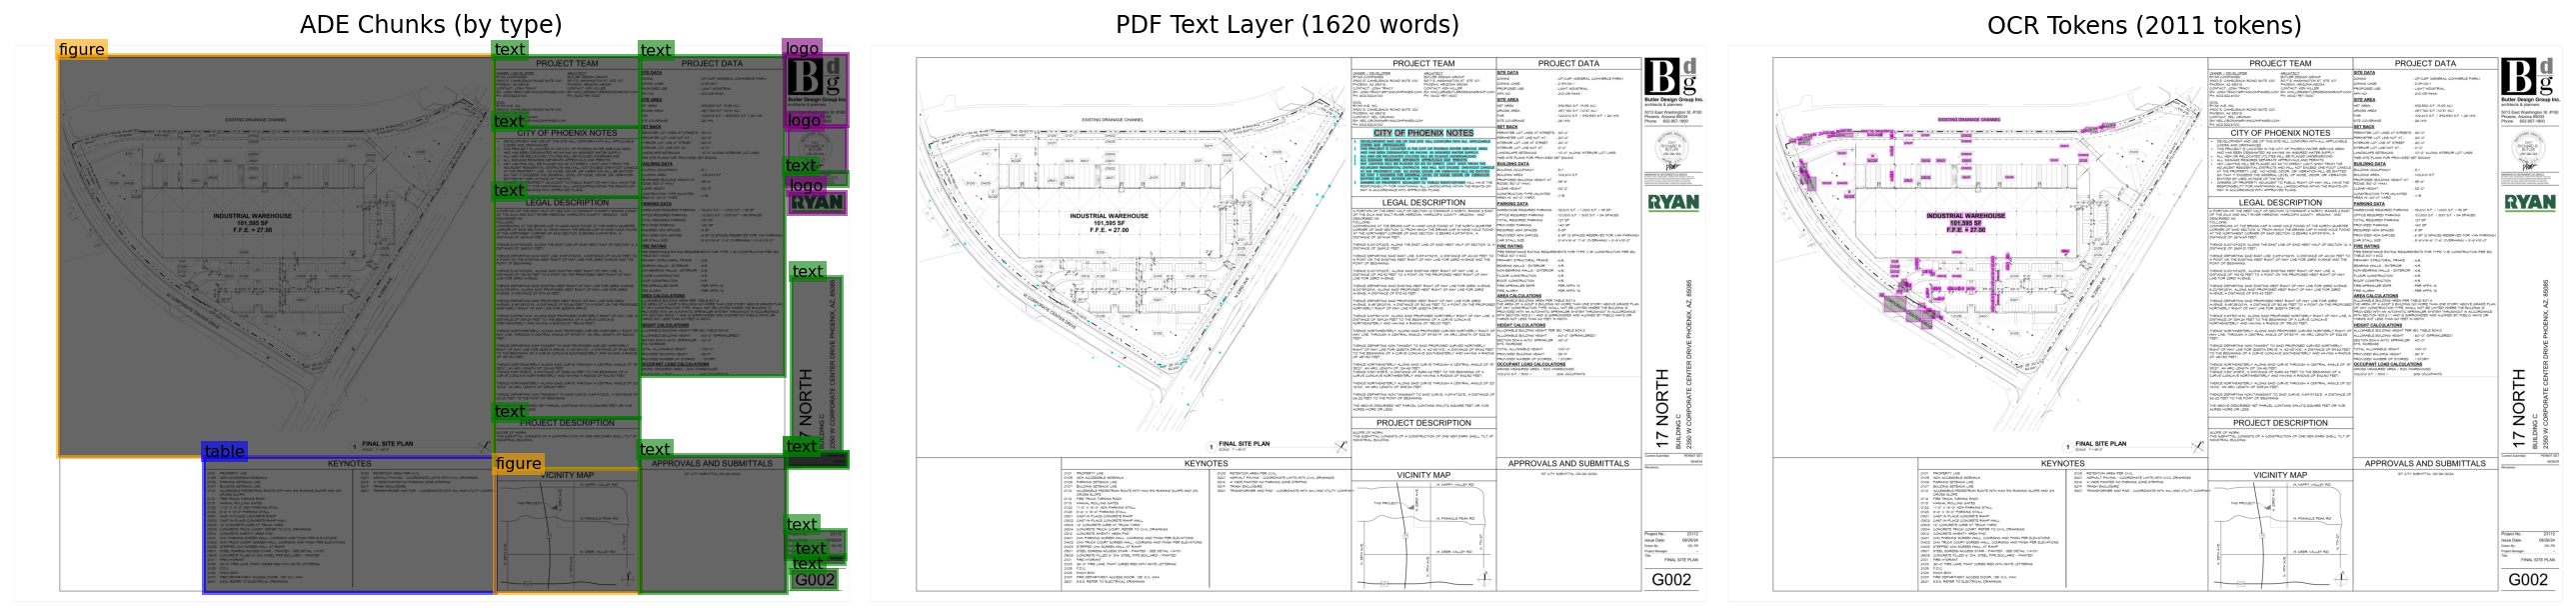

In [ ]:
# Visualization 1: All three extraction levels separately
fig, axes = plt.subplots(1, 3, figsize=(18, 14))

# ADE chunks
axes[0].imshow(page_img)
axes[0].set_axis_off()
axes[0].set_title("ADE Chunks (by type)", fontsize=12)
# Color by type
type_colors = {
    "figure": "orange",
    "architectural_drawing": "red",
    "table": "blue",
    "text": "green",
    "logo": "purple",
}
for chunk in ade_chunks:
    chunk_type = chunk.get("type", "unknown")
    color = type_colors.get(chunk_type, "gray")
    add_boxes(axes[0], [chunk], color=color, label_key="type", linewidth=2.0, alpha=0.6)

# PDF words
axes[1].imshow(page_img)
axes[1].set_axis_off()
axes[1].set_title(f"PDF Text Layer ({len(pdf_words)} words)", fontsize=12)
add_boxes(axes[1], pdf_words[:200], color="cyan", label_key=None, linewidth=0.8, alpha=0.3)

# OCR tokens
axes[2].imshow(page_img)
axes[2].set_axis_off()
axes[2].set_title(f"OCR Tokens ({len(ocr_tokens)} tokens)", fontsize=12)
add_boxes(axes[2], ocr_tokens[:200], color="magenta", label_key=None, linewidth=0.8, alpha=0.3)

plt.tight_layout()
plt.show()


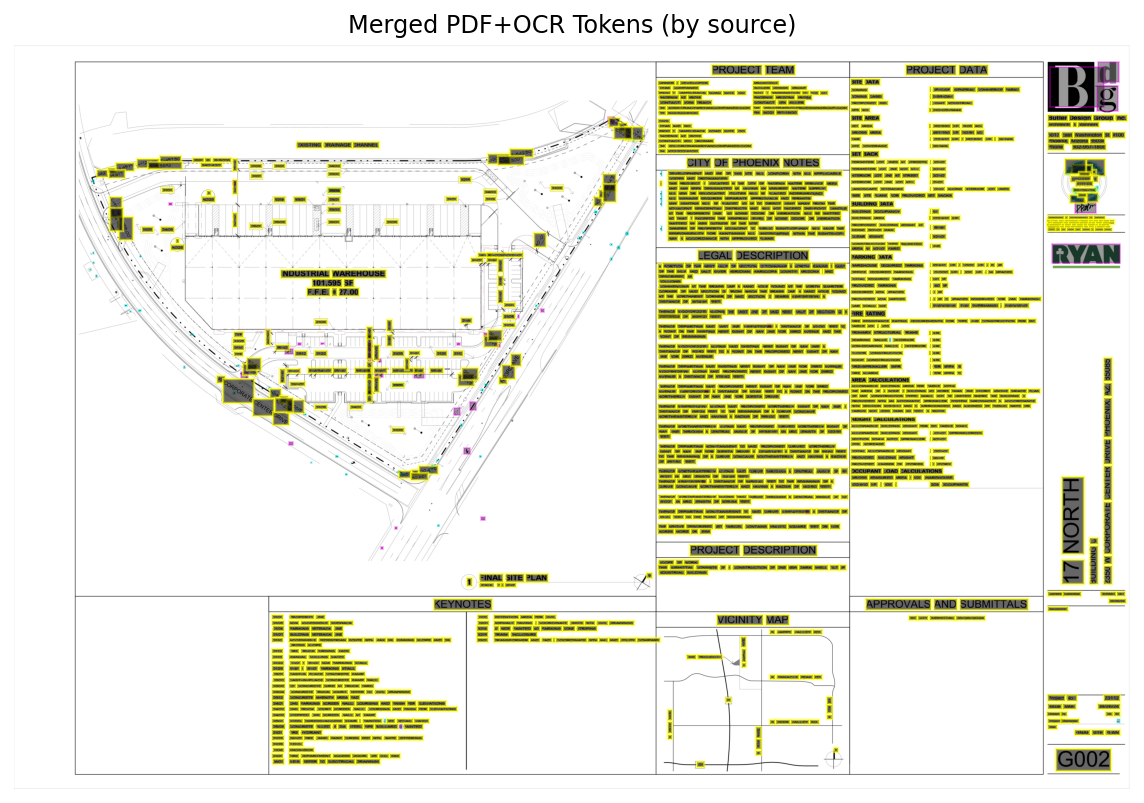

Legend:
  Cyan: PDF only (152)
  Magenta: OCR only (38)
  Yellow: PDF+OCR merged (1468)


In [ ]:
# Visualization 2: Merged tokens color-coded by source
fig, ax = show_page(title="Merged PDF+OCR Tokens (by source)")

# Separate by source
pdf_only = [t for t in merged_tokens_with_tags if t.get("source") == "pdf_only"]
ocr_only = [t for t in merged_tokens_with_tags if t.get("source") == "ocr_only"]
pdf_ocr_merged = [t for t in merged_tokens_with_tags if t.get("source") == "pdf+ocr"]

add_boxes(ax, pdf_only[:300], color="cyan", label_key=None, linewidth=0.8, alpha=0.3)
add_boxes(ax, ocr_only[:300], color="magenta", label_key=None, linewidth=0.8, alpha=0.4)
add_boxes(ax, pdf_ocr_merged, color="yellow", label_key=None, linewidth=1.2, alpha=0.6)

plt.show()

print(f"Legend:")
print(f"  Cyan: PDF only ({len(pdf_only)})")
print(f"  Magenta: OCR only ({len(ocr_only)})")
print(f"  Yellow: PDF+OCR merged ({len(pdf_ocr_merged)})")


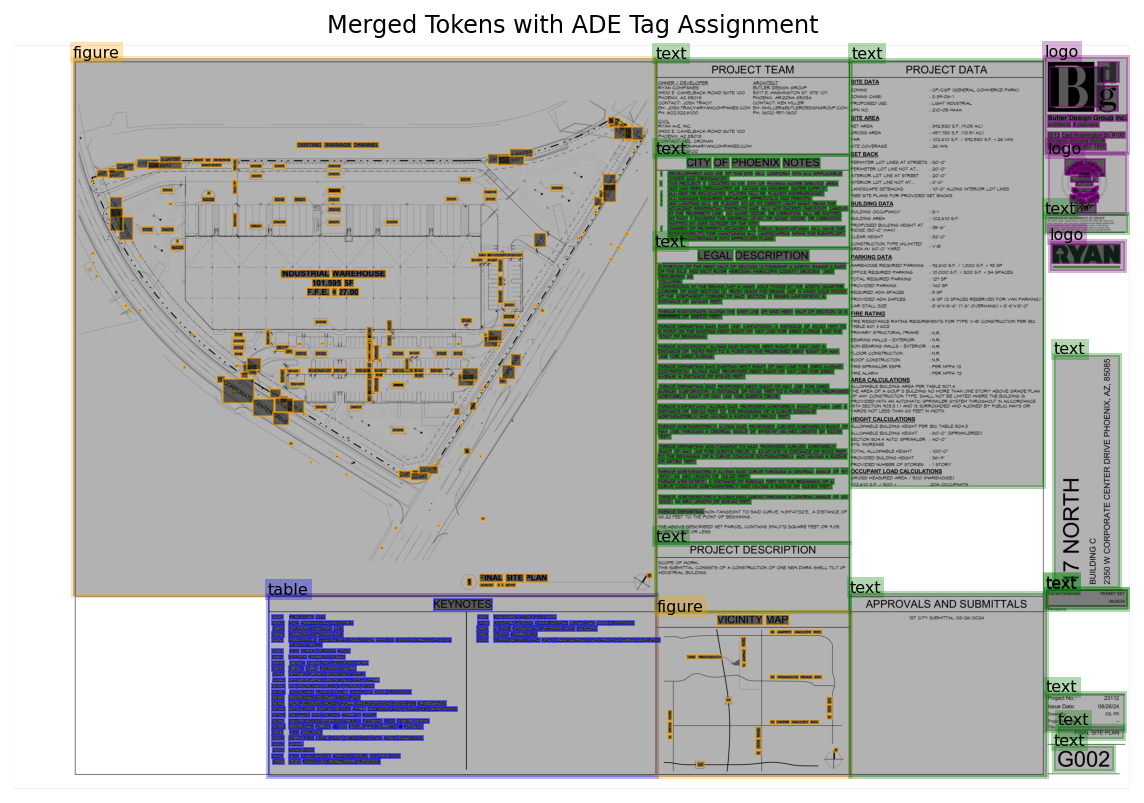

Legend:
  Orange: figure (281 tokens)
  Blue: table (198 tokens)
  Green: text (1081 tokens)
  Purple: logo (98 tokens)
  Gray: Unassigned (0 tokens)


In [ ]:
# Visualization 3: Merged tokens color-coded by ADE tag assignment
fig, ax = show_page(title="Merged Tokens with ADE Tag Assignment")

# Show ADE chunks as background
for chunk in ade_chunks:
    chunk_type = chunk.get("type", "unknown")
    color = type_colors.get(chunk_type, "gray")
    add_boxes(ax, [chunk], color=color, label_key="type", linewidth=2.0, alpha=0.3)

# Show assigned tokens
assigned_tokens = [t for t in merged_tokens_with_tags if t.get("ade_assigned")]
unassigned_tokens = [t for t in merged_tokens_with_tags if not t.get("ade_assigned")]

# Color assigned tokens by ADE type
for ade_type, color in type_colors.items():
    type_tokens = [t for t in assigned_tokens if t.get("ade_type") == ade_type]
    if type_tokens:
        add_boxes(ax, type_tokens[:500], color=color, label_key=None, linewidth=1.0, alpha=0.5)

# Show unassigned tokens in gray
add_boxes(ax, unassigned_tokens[:200], color="gray", label_key=None, linewidth=0.6, alpha=0.2)

plt.show()

print(f"Legend:")
for ade_type, color in type_colors.items():
    count = sum(1 for t in assigned_tokens if t.get("ade_type") == ade_type)
    if count > 0:
        print(f"  {color.capitalize()}: {ade_type} ({count} tokens)")
print(f"  Gray: Unassigned ({len(unassigned_tokens)} tokens)")


/home/ubuntu/leo_streamlit/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/leo_streamlit/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12467 (\N{KATAKANA LETTER KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/leo_streamlit/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


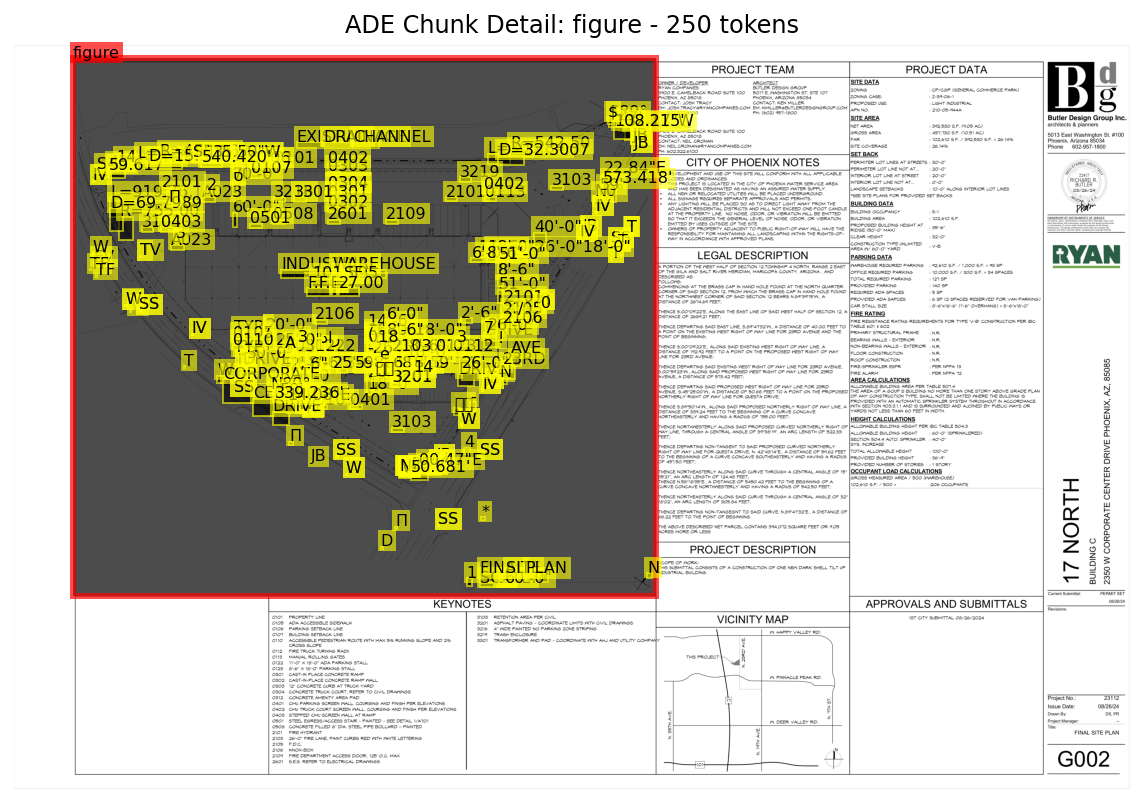


Selected chunk:
  Type: figure
  ID: 1723b0dc-6eb8-4a5d-830b-ac7e09b673c3
  Tokens assigned: 250
  Bounding box: (136.1, 32.0) - (1489.2, 1280.0)

Sample token texts:
  1. T
  2. T
  3. EV
  4. JB
  5. W
  6. W
  7. TF
  8. TF
  9. JB
  10. JB


In [ ]:
# Visualization 4: Detailed view - one ADE chunk with its assigned tokens
if ade_chunks:
    # Pick first non-logo chunk for detailed view
    selected_chunk = None
    for chunk in ade_chunks:
        if chunk.get("type", "").lower() != "logo":
            selected_chunk = chunk
            break
    
    if not selected_chunk:
        selected_chunk = ade_chunks[0]
    
    chunk_tokens = [
        t
        for t in merged_tokens_with_tags
        if t.get("ade_id") == selected_chunk.get("id")
    ]
    
    fig, ax = show_page(title=f"ADE Chunk Detail: {selected_chunk.get('type')} - {len(chunk_tokens)} tokens")
    
    # Show the chunk boundary
    add_boxes(ax, [selected_chunk], color="red", label_key="type", linewidth=3.0, alpha=0.7)
    
    # Show assigned tokens
    add_boxes(ax, chunk_tokens, color="yellow", label_key="text", linewidth=1.0, alpha=0.6)
    
    plt.show()
    
    print(f"\nSelected chunk:")
    print(f"  Type: {selected_chunk.get('type')}")
    print(f"  ID: {selected_chunk.get('id')}")
    print(f"  Tokens assigned: {len(chunk_tokens)}")
    print(f"  Bounding box: ({selected_chunk.get('x0'):.1f}, {selected_chunk.get('y0'):.1f}) - ({selected_chunk.get('x1'):.1f}, {selected_chunk.get('y1'):.1f})")
    
    if chunk_tokens:
        sample_texts = [t.get("text", "")[:30] for t in chunk_tokens[:10]]
        print(f"\nSample token texts:")
        for idx, text in enumerate(sample_texts, 1):
            print(f"  {idx}. {text}")


## Step 5: Summary Statistics


In [ ]:
# Create summary statistics
summary = {
    "extraction_levels": {
        "pdf_words": len(pdf_words),
        "ocr_tokens": len(ocr_tokens),
        "ade_chunks": len(ade_chunks),
    },
    "merge_results": {
        "total_merged_tokens": len(merged_tokens_with_tags),
        "pdf_only": len([t for t in merged_tokens_with_tags if t.get("source") == "pdf_only"]),
        "ocr_only": len([t for t in merged_tokens_with_tags if t.get("source") == "ocr_only"]),
        "pdf_ocr_merged": len([t for t in merged_tokens_with_tags if t.get("source") == "pdf+ocr"]),
    },
    "ade_assignment": {
        "assigned": len([t for t in merged_tokens_with_tags if t.get("ade_assigned")]),
        "unassigned": len([t for t in merged_tokens_with_tags if not t.get("ade_assigned")]),
        "assignment_rate": len([t for t in merged_tokens_with_tags if t.get("ade_assigned")])
        / len(merged_tokens_with_tags)
        if merged_tokens_with_tags
        else 0.0,
    },
    "ade_types": {}
}

# Count by ADE type
for chunk in ade_chunks:
    chunk_type = chunk.get("type", "unknown")
    summary["ade_types"][chunk_type] = summary["ade_types"].get(chunk_type, 0) + 1

# Count tokens per ADE type
tokens_per_type = {}
for token in merged_tokens_with_tags:
    if token.get("ade_assigned"):
        ade_type = token.get("ade_type", "unknown")
        tokens_per_type[ade_type] = tokens_per_type.get(ade_type, 0) + 1

print("📊 Summary Statistics")
print("=" * 50)
print("\nExtraction Levels:")
for level, count in summary["extraction_levels"].items():
    print(f"  {level}: {count}")

print("\nMerge Results:")
for result, count in summary["merge_results"].items():
    print(f"  {result}: {count}")

print("\nADE Assignment:")
for key, value in summary["ade_assignment"].items():
    if isinstance(value, float):
        print(f"  {key}: {value:.2%}")
    else:
        print(f"  {key}: {value}")

print("\nADE Chunks by Type:")
for ade_type, count in sorted(summary["ade_types"].items()):
    tokens_count = tokens_per_type.get(ade_type, 0)
    print(f"  {ade_type}: {count} chunks, {tokens_count} tokens")

# Display as DataFrame
summary_df = pd.DataFrame([
    {"Metric": "PDF Words", "Count": summary["extraction_levels"]["pdf_words"]},
    {"Metric": "OCR Tokens", "Count": summary["extraction_levels"]["ocr_tokens"]},
    {"Metric": "ADE Chunks", "Count": summary["extraction_levels"]["ade_chunks"]},
    {"Metric": "Merged Tokens", "Count": summary["merge_results"]["total_merged_tokens"]},
    {"Metric": "PDF Only", "Count": summary["merge_results"]["pdf_only"]},
    {"Metric": "OCR Only", "Count": summary["merge_results"]["ocr_only"]},
    {"Metric": "PDF+OCR Merged", "Count": summary["merge_results"]["pdf_ocr_merged"]},
    {"Metric": "ADE Assigned", "Count": summary["ade_assignment"]["assigned"]},
    {"Metric": "ADE Unassigned", "Count": summary["ade_assignment"]["unassigned"]},
    {"Metric": "Assignment Rate", "Count": f"{summary['ade_assignment']['assignment_rate']:.2%}"},
])

display(summary_df)


📊 Summary Statistics

Extraction Levels:
  pdf_words: 1620
  ocr_tokens: 2011
  ade_chunks: 19

Merge Results:
  total_merged_tokens: 1658
  pdf_only: 152
  ocr_only: 38
  pdf_ocr_merged: 1468

ADE Assignment:
  assigned: 1658
  unassigned: 0
  assignment_rate: 100.00%

ADE Chunks by Type:
  figure: 2 chunks, 281 tokens
  logo: 3 chunks, 98 tokens
  table: 1 chunks, 198 tokens
  text: 13 chunks, 1081 tokens


,Metric,Count
0,PDF Words,1620
1,OCR Tokens,2011
2,ADE Chunks,19
3,Merged Tokens,1658
4,PDF Only,152
5,OCR Only,38
6,PDF+OCR Merged,1468
7,ADE Assigned,1658
8,ADE Unassigned,0
9,Assignment Rate,100.00%


## Final Consolidated Table

Complete table with all tokens, their bounding boxes, sources, and ADE tags.


In [ ]:
# Create final consolidated table with all tokens, bounding boxes, and ADE tags
final_table_data = []

for token in merged_tokens_with_tags:
    row = {
        # Token information
        "text": token.get("text", ""),
        "normalized_text": token.get("normalized_text", ""),
        
        # Bounding box
        "x0": round(float(token.get("x0", 0)), 2),
        "y0": round(float(token.get("y0", 0)), 2),
        "x1": round(float(token.get("x1", 0)), 2),
        "y1": round(float(token.get("y1", 0)), 2),
        "width": round(float(token.get("x1", 0)) - float(token.get("x0", 0)), 2),
        "height": round(float(token.get("y1", 0)) - float(token.get("y0", 0)), 2),
        
        # Source information
        "source": token.get("source", "unknown"),
        "sources_count": token.get("sources_count", 1),
        "original_pdf_text": token.get("original_pdf_text", ""),
        "original_ocr_text": token.get("original_ocr_text", ""),
        
        # ADE tag information
        "ade_assigned": token.get("ade_assigned", False),
        "ade_id": token.get("ade_id", None),
        "ade_type": token.get("ade_type", None),
        "ade_overlap_ratio": round(float(token.get("ade_overlap_ratio", 0)), 3) if token.get("ade_assigned") else None,
        "ade_iou": round(float(token.get("ade_iou", 0)), 3) if token.get("ade_assigned") else None,
        "ade_is_contained": token.get("ade_is_contained", False) if token.get("ade_assigned") else None,
        "ade_score": round(float(token.get("ade_score", 0)), 3) if token.get("ade_assigned") else None,
        
        # ADE chunk bounding box (if assigned)
        "ade_chunk_x0": round(float(token.get("ade_x0", 0)), 2) if token.get("ade_assigned") else None,
        "ade_chunk_y0": round(float(token.get("ade_y0", 0)), 2) if token.get("ade_assigned") else None,
        "ade_chunk_x1": round(float(token.get("ade_x1", 0)), 2) if token.get("ade_assigned") else None,
        "ade_chunk_y1": round(float(token.get("ade_y1", 0)), 2) if token.get("ade_assigned") else None,
    }
    final_table_data.append(row)

# Create DataFrame
final_table_df = pd.DataFrame(final_table_data)

print(f"📋 Final Consolidated Table")
print(f"   Total tokens: {len(final_table_df)}")
print(f"   Columns: {len(final_table_df.columns)}")
print(f"\n📊 Breakdown:")
print(f"   ADE assigned: {final_table_df['ade_assigned'].sum()}")
print(f"   ADE unassigned: {(~final_table_df['ade_assigned']).sum()}")

# Show the full table
print(f"\n📄 Complete Table (first 50 rows):")
display(final_table_df.head(50))

# Show summary by ADE type
if final_table_df["ade_assigned"].any():
    print(f"\n📈 Summary by ADE Type:")
    ade_type_summary = final_table_df[final_table_df["ade_assigned"]].groupby("ade_type").agg({
        "text": "count",
        "ade_overlap_ratio": "mean",
        "ade_iou": "mean",
        "ade_is_contained": "sum"
    }).rename(columns={
        "text": "token_count",
        "ade_overlap_ratio": "avg_overlap",
        "ade_iou": "avg_iou",
        "ade_is_contained": "contained_count"
    })
    ade_type_summary["contained_pct"] = (
        ade_type_summary["contained_count"] / ade_type_summary["token_count"] * 100
    ).round(1)
    display(ade_type_summary)

# Export option
print(f"\n💾 Table is available as 'final_table_df'")
print(f"   You can export it with: final_table_df.to_csv('output.csv') or final_table_df.to_excel('output.xlsx')")


📋 Final Consolidated Table
   Total tokens: 1658
   Columns: 23

📊 Breakdown:
   ADE assigned: 1658
   ADE unassigned: 0

📄 Complete Table (first 50 rows):


,text,normalized_text,x0,y0,x1,y1,width,height,source,sources_count,original_pdf_text,original_ocr_text,ade_assigned,ade_id,ade_type,ade_overlap_ratio,ade_iou,ade_is_contained,ade_score,ade_chunk_x0,ade_chunk_y0,ade_chunk_x1,ade_chunk_y1
0,T,T,1401.09,468.66,1405.28,473.54,4.19,4.88,pdf_only,1,T,,True,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,figure,1.0,0.0,True,1.5,0.0,0.0,0.0,0.0
1,T,T,1421.13,436.02,1425.32,440.90,4.19,4.88,pdf_only,1,T,,True,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,figure,1.0,0.0,True,1.5,0.0,0.0,0.0,0.0
2,EV,EV,183.32,505.48,185.68,507.64,2.37,2.16,pdf_only,1,EV,,True,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,figure,1.0,0.0,True,1.5,0.0,0.0,0.0,0.0
3,JB,J8,688.07,969.01,690.76,971.52,2.69,2.52,pdf_only,1,JB,,True,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,figure,1.0,0.0,True,1.5,0.0,0.0,0.0,0.0
4,W,W,182.16,482.25,184.87,485.00,2.71,2.75,pdf_only,1,W,,True,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,figure,1.0,0.0,True,1.5,0.0,0.0,0.0,0.0
5,W,W,268.68,618.33,271.39,621.08,2.71,2.75,pdf_only,1,W,,True,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,figure,1.0,0.0,True,1.5,0.0,0.0,0.0,0.0
6,TF,TF,174.64,521.23,177.27,523.84,2.64,2.61,pdf_only,1,TF,,True,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,figure,1.0,0.0,True,1.5,0.0,0.0,0.0,0.0
7,TF,TF,189.76,535.87,192.39,538.48,2.64,2.61,pdf_only,1,TF,,True,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,figure,1.0,0.0,True,1.5,0.0,0.0,0.0,0.0
8,JB,J8,1436.63,222.13,1439.32,224.64,2.69,2.52,pdf_only,1,JB,,True,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,figure,1.0,0.0,True,1.5,0.0,0.0,0.0,0.0
9,JB,J8,1439.51,241.57,1442.20,244.08,2.69,2.52,pdf_only,1,JB,,True,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,figure,1.0,0.0,True,1.5,0.0,0.0,0.0,0.0



📈 Summary by ADE Type:


,token_count,avg_overlap,avg_iou,contained_count,contained_pct
ade_type,,,,,
figure,281,1.000000,0.000342,281,100.0
logo,98,1.000000,0.016694,98,100.0
table,198,0.999374,0.001020,198,100.0
text,1081,0.998640,0.003862,1081,100.0



💾 Table is available as 'final_table_df'
   You can export it with: final_table_df.to_csv('output.csv') or final_table_df.to_excel('output.xlsx')


In [ ]:
# Optional: Create a simplified version with just the essential columns
essential_columns = [
    "text",
    "x0", "y0", "x1", "y1",
    "source",
    "ade_type",
    "ade_id",
    "ade_is_contained",
]

simplified_table_df = final_table_df[essential_columns].copy()

print("📋 Simplified Table (Essential Columns Only):")
print(f"   Total tokens: {len(simplified_table_df)}")
print(f"   Columns: {len(simplified_table_df.columns)}")
print(f"\n   Columns: {', '.join(simplified_table_df.columns)}")

display(simplified_table_df.head(50))

print(f"\n💾 Simplified table is available as 'simplified_table_df'")


📋 Simplified Table (Essential Columns Only):
   Total tokens: 1658
   Columns: 9

   Columns: text, x0, y0, x1, y1, source, ade_type, ade_id, ade_is_contained


,text,x0,y0,x1,y1,source,ade_type,ade_id,ade_is_contained
0,T,1401.09,468.66,1405.28,473.54,pdf_only,figure,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,True
1,T,1421.13,436.02,1425.32,440.90,pdf_only,figure,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,True
2,EV,183.32,505.48,185.68,507.64,pdf_only,figure,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,True
3,JB,688.07,969.01,690.76,971.52,pdf_only,figure,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,True
4,W,182.16,482.25,184.87,485.00,pdf_only,figure,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,True
5,W,268.68,618.33,271.39,621.08,pdf_only,figure,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,True
6,TF,174.64,521.23,177.27,523.84,pdf_only,figure,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,True
7,TF,189.76,535.87,192.39,538.48,pdf_only,figure,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,True
8,JB,1436.63,222.13,1439.32,224.64,pdf_only,figure,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,True
9,JB,1439.51,241.57,1442.20,244.08,pdf_only,figure,1723b0dc-6eb8-4a5d-830b-ac7e09b673c3,True



💾 Simplified table is available as 'simplified_table_df'


In [ ]:
# Cleanup
pdf_doc.close()
